In [5]:
# !pip install --upgrade scikit-learn
!pip install scikit-learn auto-sklearn

!pip install kaggle

!pip install kagglehub

# For dataset manipulation
!pip install datasets -q

!pip install numpy scipy xgboost

!pip install --upgrade pip setuptools wheel

!pip install unzip pandas

!pip install matplotlib seaborn yellowbrick xgboost lightgbm plotly

  Using cached auto-sklearn-0.15.0.tar.gz (6.5 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached scikit-learn-0.24.2.tar.gz (7.5 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... error
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [20 lines of output]
      <string>:17: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
      Partial import of sklearn during the build process.
      Traceback (most recent call last):
        File "/opt/anaconda3/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks/_in_process/_in_process.py", line 353, in <module>
          main()
        File "/opt/anaconda3/lib/python3.12/site-packages/pip/_vendor/pyproject_hooks

In [16]:
!pip install --upgrade pip setuptools wheel
!pip install numpy pandas matplotlib seaborn scikit-learn xgboost

In [21]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [11]:
# Then move kaggle.json into the folder where the API expects to find it.
# !mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

In [12]:
!kaggle competitions download -c hearth-disease-recognition

 93%|███████████████████████████████████▍  | 4.00M/4.30M [00:02<00:00, 1.93MB/s]
100%|██████████████████████████████████████| 4.30M/4.30M [00:02<00:00, 1.89MB/s]


In [13]:
import shutil

zip_path = "hearth-disease-recognition.zip"
extract_path = "dataset"

shutil.unpack_archive(zip_path, extract_path)
print("✅ แตกไฟล์สำเร็จ!")

✅ แตกไฟล์สำเร็จ!


In [1]:
!pip  install xgboost

In [6]:
# 1. to handle the data
import pandas as pd
import numpy as np

# 2. To Viusalize the data
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.colors import ListedColormap

# 3. To preprocess the data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer

# 4. import Iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 5. Machine Learning
from sklearn.model_selection import train_test_split,GridSearchCV, cross_val_score

# 6. For Classification task.
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,ExtraTreesClassifier,RandomForestRegressor
from xgboost import XGBClassifier

# 7. Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 8. Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# improt ALl models.
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB

#importing pipeline
from sklearn.pipeline import Pipeline

# import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error, mean_squared_error, r2_score



In [22]:
import platform
print(platform.architecture())

('64bit', 'Mach-O')


In [8]:

df = pd.read_csv('dataset/train.csv')

df.head()

,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,train_000001,No,Yes,Yes,Yes,40.68,Yes,No,No,No,No,Yes,No,Very Poor,Yes,Female,High school graduate,"$15,000 to less than $20,000",64,Yes
1,train_000002,No,No,No,No,24.36,Yes,No,No,Yes,No,No,Yes,Fair,No,Female,College graduate,"Less than $10,000",50,No
2,train_000003,No,Yes,Yes,Yes,27.33,No,No,No,No,No,Yes,Yes,Very Poor,Yes,Female,High school graduate,"$75,000 or more",61,Yes
3,train_000004,No,Yes,No,Yes,27.01,No,No,No,Yes,No,Yes,No,Good,No,Female,Some high school,"$35,000 to less than $50,000",74,Yes
4,train_000005,NaN,Yes,Yes,Yes,34.56,Yes,No,No,Yes,No,Yes,Yes,Very Poor,Yes,Male,Some high school,"$15,000 to less than $20,000",98,Yes


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223084 entries, 0 to 223083
Data columns (total 20 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      223084 non-null  object 
 1   History of HeartDisease or Attack       221390 non-null  object 
 2   High Blood Pressure                     223084 non-null  object 
 3   Told High Cholesterol                   190898 non-null  object 
 4   Cholesterol Checked                     223084 non-null  object 
 5   Body Mass Index                         211302 non-null  float64
 6   Smoked 100+ Cigarettes                  223083 non-null  object 
 7   Diagnosed Stroke                        223084 non-null  object 
 8   Diagnosed Diabetes                      223081 non-null  object 
 9   Leisure Physical Activity               223084 non-null  object 
 10  Heavy Alcohol Consumption               2230

In [10]:
df.shape

(223084, 20)

In [11]:
df.columns

Index(['ID', 'History of HeartDisease or Attack', 'High Blood Pressure',
       'Told High Cholesterol', 'Cholesterol Checked', 'Body Mass Index',
       'Smoked 100+ Cigarettes', 'Diagnosed Stroke', 'Diagnosed Diabetes',
       'Leisure Physical Activity', 'Heavy Alcohol Consumption',
       'Health Care Coverage', 'Doctor Visit Cost Barrier', 'General Health',
       'Difficulty Walking', 'Sex', 'Education Level', 'Income Level', 'Age',
       'Vegetable or Fruit Intake (1+ per Day)'],
      dtype='object')

In [13]:
df.rename(columns={
    'ID': 'ID',
    'History of HeartDisease or Attack': 'HeartDisease',
    'High Blood Pressure': 'HighBP',
    'Told High Cholesterol': 'HighChol',
    'Cholesterol Checked': 'CholCheck',
    'Body Mass Index': 'BMI',
    'Smoked 100+ Cigarettes': 'Smoker',
    'Diagnosed Stroke': 'Stroke',
    'Diagnosed Diabetes': 'Diabetes',
    'Leisure Physical Activity': 'PhysicalAct',
    'Heavy Alcohol Consumption': 'Alcohol',
    'Health Care Coverage': 'HealthCov',
    'Doctor Visit Cost Barrier': 'CostBarrier',
    'General Health': 'GenHealth',
    'Difficulty Walking': 'WalkDiff',
    'Sex': 'Sex',
    'Education Level': 'EduLevel',
    'Income Level': 'Income',
    'Age': 'Age',
    'Vegetable or Fruit Intake (1+ per Day)': 'VegFruit'
}, inplace=True)


In [14]:
df.columns

Index(['ID', 'HeartDisease', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysicalAct', 'Alcohol', 'HealthCov',
       'CostBarrier', 'GenHealth', 'WalkDiff', 'Sex', 'EduLevel', 'Income',
       'Age', 'VegFruit'],
      dtype='object')

In [15]:
df['HeartDisease'].describe()

count     221390
unique         2
top           No
freq      203322
Name: HeartDisease, dtype: object

In [16]:
nan_rows = df[df['HeartDisease'].isna()]
nan_rows

,ID,HeartDisease,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysicalAct,Alcohol,HealthCov,CostBarrier,GenHealth,WalkDiff,Sex,EduLevel,Income,Age,VegFruit
4,train_000005,NaN,Yes,Yes,Yes,34.56,Yes,No,No,Yes,No,Yes,Yes,Very Poor,Yes,Male,Some high school,"$15,000 to less than $20,000",98,Yes
64,train_000065,NaN,Yes,Yes,Yes,29.76,No,Yes,Yes,Yes,No,Yes,No,Poor,No,Female,Elementary,"$15,000 to less than $20,000",98,No
135,train_000136,NaN,Yes,Yes,Yes,27.17,Yes,No,Yes,Yes,No,No,No,Fair,No,Female,Elementary,"$20,000 to less than $25,000",57,No
190,train_000191,NaN,Yes,Yes,Yes,27.03,Yes,No,Yes,Yes,No,Yes,No,Poor,Yes,Male,Some high school,"$25,000 to less than $35,000",100,Yes
296,train_000297,NaN,No,Yes,Yes,26.16,No,No,No,No,No,Yes,No,Good,No,Male,Some college or technical school,"$75,000 or more",56,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222419,train_222420,NaN,No,No,Yes,32.05,Yes,No,No,No,No,Yes,No,Poor,No,Female,Some high school,"($10,000 to less than $15,000",35,Yes
222610,train_222611,NaN,Yes,Yes,Yes,24.98,No,No,Yes,Yes,No,Yes,No,Poor,Yes,Female,Elementary,"Less than $10,000",60,No
222627,train_222628,NaN,No,No,Yes,20.25,Yes,No,No,No,No,Yes,No,Fair,Yes,Male,Some high school,"Less than $10,000",32,Yes
222640,train_222641,NaN,Yes,Yes,Yes,24.30,No,No,Yes,Yes,No,Yes,No,Fair,No,Male,Some college or technical school,"($10,000 to less than $15,000",58,Yes


<Axes: xlabel='HeartDisease', ylabel='count'>

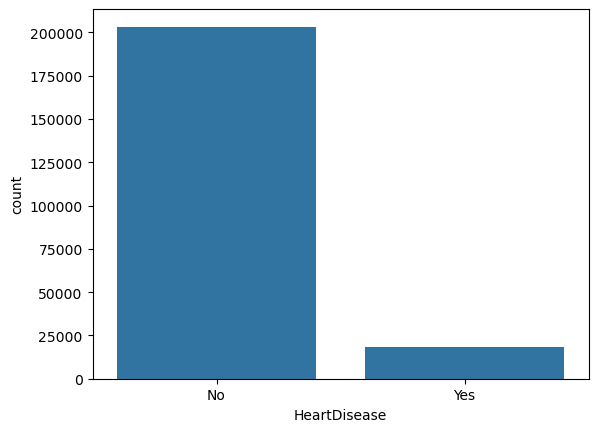

In [17]:
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'

custom_colors = ["#FF5733", "#3366FF", "#33FF57"]  # Example colors, you can adjust as needed

sns.countplot(df, x='HeartDisease')

In [ ]:
df['HeartDisease'].value_counts()

,count
HeartDisease,
No,203322
Yes,18068


In [ ]:
df = df.dropna(subset=['HeartDisease'])
df

,ID,HeartDisease,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysicalAct,Alcohol,HealthCov,CostBarrier,GenHealth,WalkDiff,Sex,EduLevel,Income,Age,VegFruit
0,train_000001,No,Yes,Yes,Yes,40.68,Yes,No,No,No,No,Yes,No,Very Poor,Yes,Female,High school graduate,"$15,000 to less than $20,000",64,Yes
1,train_000002,No,No,No,No,24.36,Yes,No,No,Yes,No,No,Yes,Fair,No,Female,College graduate,"Less than $10,000",50,No
2,train_000003,No,Yes,Yes,Yes,27.33,No,No,No,No,No,Yes,Yes,Very Poor,Yes,Female,High school graduate,"$75,000 or more",61,Yes
3,train_000004,No,Yes,No,Yes,27.01,No,No,No,Yes,No,Yes,No,Good,No,Female,Some high school,"$35,000 to less than $50,000",74,Yes
5,train_000006,No,Yes,Yes,Yes,25.11,Yes,No,No,Yes,No,Yes,No,Good,No,Male,College graduate,"$75,000 or more",67,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223079,train_223080,No,No,No,Yes,28.20,No,No,No,No,No,Yes,No,Excellent,No,Female,College graduate,"$25,000 to less than $35,000",34,Yes
223080,train_223081,No,Yes,Yes,Yes,45.01,No,No,No,No,No,Yes,No,Fair,No,Male,College graduate,"$50,000 to less than $75,000",43,Yes
223081,train_223082,No,Yes,Yes,Yes,18.94,No,No,Yes,No,No,Yes,No,Poor,Yes,Female,Elementary,"$20,000 to less than $25,000",72,No
223082,train_223083,No,No,No,Yes,29.29,No,No,No,Yes,No,Yes,No,Excellent,No,Female,Some college or technical school,"($10,000 to less than $15,000",28,Yes


In [ ]:
h_rows = df[(df['HeartDisease'] == 1)]
h_rows

,ID,HeartDisease,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysicalAct,Alcohol,HealthCov,CostBarrier,GenHealth,WalkDiff,Sex,EduLevel,Income,Age,VegFruit


In [ ]:
df_train = pd.read_csv('/content/dataset/train.csv')

In [ ]:
df_h = df_train[df_train['History of HeartDisease or Attack'] == 'Yes']
df_train[(df_train['History of HeartDisease or Attack'] == 'Yes') & (df_train['Told High Cholesterol'] == 'Yes')]

,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
7,train_000008,Yes,Yes,Yes,Yes,29.84,Yes,No,Yes,No,No,Yes,No,Very Poor,Yes,Female,Some college or technical school,"Less than $10,000",64,Yes
21,train_000022,Yes,Yes,Yes,Yes,22.38,No,Yes,No,No,No,Yes,No,Fair,Yes,Female,High school graduate,"$20,000 to less than $25,000",75,Yes
27,train_000028,Yes,Yes,Yes,Yes,37.46,Yes,Yes,Yes,No,No,Yes,No,Very Poor,Yes,Male,College graduate,"$25,000 to less than $35,000",65,Yes
29,train_000030,Yes,Yes,Yes,Yes,27.55,Yes,No,Yes,No,No,Yes,No,Poor,No,Male,Elementary,"$20,000 to less than $25,000",76,Yes
43,train_000044,Yes,Yes,Yes,Yes,25.94,Yes,No,No,No,No,Yes,No,Good,No,Male,High school graduate,"$50,000 to less than $75,000",66,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223006,train_223007,Yes,Yes,Yes,Yes,NaN,Yes,No,No,No,No,Yes,No,Poor,Yes,Female,High school graduate,"Less than $10,000",58,Yes
223015,train_223016,Yes,Yes,Yes,Yes,17.99,No,No,No,No,No,Yes,No,Very Poor,Yes,Male,High school graduate,"$15,000 to less than $20,000",75,Yes
223042,train_223043,Yes,Yes,Yes,Yes,28.18,No,No,Yes,Yes,No,Yes,Yes,Poor,No,Male,High school graduate,"$25,000 to less than $35,000",64,Yes
223072,train_223073,Yes,No,Yes,Yes,28.62,Yes,No,Yes,No,No,Yes,No,Good,Yes,Male,Some high school,"$35,000 to less than $50,000",67,Yes


In [ ]:
df_n = df_train[(df_train['History of HeartDisease or Attack'] != 'Yes') & (df_train['History of HeartDisease or Attack'] == 'No')]
df_n

,ID,History of HeartDisease or Attack,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,train_000001,No,Yes,Yes,Yes,40.68,Yes,No,No,No,No,Yes,No,Very Poor,Yes,Female,High school graduate,"$15,000 to less than $20,000",64,Yes
1,train_000002,No,No,No,No,24.36,Yes,No,No,Yes,No,No,Yes,Fair,No,Female,College graduate,"Less than $10,000",50,No
2,train_000003,No,Yes,Yes,Yes,27.33,No,No,No,No,No,Yes,Yes,Very Poor,Yes,Female,High school graduate,"$75,000 or more",61,Yes
3,train_000004,No,Yes,No,Yes,27.01,No,No,No,Yes,No,Yes,No,Good,No,Female,Some high school,"$35,000 to less than $50,000",74,Yes
5,train_000006,No,Yes,Yes,Yes,25.11,Yes,No,No,Yes,No,Yes,No,Good,No,Male,College graduate,"$75,000 or more",67,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223079,train_223080,No,No,No,Yes,28.20,No,No,No,No,No,Yes,No,Excellent,No,Female,College graduate,"$25,000 to less than $35,000",34,Yes
223080,train_223081,No,Yes,Yes,Yes,45.01,No,No,No,No,No,Yes,No,Fair,No,Male,College graduate,"$50,000 to less than $75,000",43,Yes
223081,train_223082,No,Yes,Yes,Yes,18.94,No,No,Yes,No,No,Yes,No,Poor,Yes,Female,Elementary,"$20,000 to less than $25,000",72,No
223082,train_223083,No,No,No,Yes,29.29,No,No,No,Yes,No,Yes,No,Excellent,No,Female,Some college or technical school,"($10,000 to less than $15,000",28,Yes


In [ ]:
df['HeartDisease'].unique()

array(['No', 'Yes'], dtype=object)

## Explore HighBP
Unique: ['Yes', 'No']
Type: Boolean
Have NaN: false

In [ ]:
df['HighBP'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
nan_rows = df[df['HighBP'].isna()]
nan_rows

,ID,HeartDisease,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysicalAct,Alcohol,HealthCov,CostBarrier,GenHealth,WalkDiff,Sex,EduLevel,Income,Age,VegFruit


In [ ]:
nan_rows = df[(df['HighChol'].isna()) & (df['HeartDisease'] == 'Yes')]
nan_rows

,ID,HeartDisease,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysicalAct,Alcohol,HealthCov,CostBarrier,GenHealth,WalkDiff,Sex,EduLevel,Income,Age,VegFruit
315,train_000316,Yes,Yes,NaN,No,15.01,No,No,No,No,No,Yes,No,Fair,Yes,Female,Some high school,"$20,000 to less than $25,000",88,No
1018,train_001019,Yes,Yes,NaN,No,41.62,No,Yes,Yes,No,No,Yes,No,Poor,Yes,Female,Some high school,"($10,000 to less than $15,000",43,Yes
1877,train_001878,Yes,Yes,NaN,No,20.55,Yes,Yes,No,No,No,No,Yes,Very Poor,Yes,Female,High school graduate,"Less than $10,000",33,Yes
2073,train_002074,Yes,No,NaN,No,28.54,Yes,No,No,Yes,No,Yes,No,Poor,Yes,Female,Some college or technical school,"($10,000 to less than $15,000",46,Yes
2151,train_002152,Yes,No,NaN,No,40.38,No,No,No,No,No,Yes,No,Good,No,Female,High school graduate,"$50,000 to less than $75,000",38,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222670,train_222671,Yes,Yes,NaN,No,23.16,No,No,No,No,No,Yes,No,Poor,No,Female,College graduate,"$20,000 to less than $25,000",70,Yes
222717,train_222718,Yes,No,NaN,No,25.15,No,No,No,Yes,No,Yes,Yes,Good,Yes,Female,College graduate,"$15,000 to less than $20,000",24,Yes
222777,train_222778,Yes,Yes,NaN,No,37.75,No,No,No,No,No,Yes,Yes,Very Poor,Yes,Female,College graduate,"$25,000 to less than $35,000",43,Yes
222829,train_222830,Yes,No,NaN,No,24.37,No,No,No,No,No,Yes,No,Poor,No,Male,Some high school,"($10,000 to less than $15,000",35,No


## Explore CholCheck

Unique: ['Yes', 'No']

Type: Boolean

Have NaN: false

In [ ]:
df['CholCheck'].describe()
df['CholCheck'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
nan_rows = df[(df['CholCheck'].isna())]
nan_rows

,ID,HeartDisease,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysicalAct,Alcohol,HealthCov,CostBarrier,GenHealth,WalkDiff,Sex,EduLevel,Income,Age,VegFruit


## Explore BMI

Unique: ['Yes', 'No']

Type: Boolean

Have NaN: false

In [ ]:
df['BMI'].describe()

,BMI
count,209665.000000
mean,28.181723
std,6.686984
min,11.210000
25%,23.870000
50%,27.060000
75%,31.080000
max,98.630000


In [ ]:
nan_rows = df[df['BMI'].isna()]
nan_rows

,ID,HeartDisease,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysicalAct,Alcohol,HealthCov,CostBarrier,GenHealth,WalkDiff,Sex,EduLevel,Income,Age,VegFruit
22,train_000023,No,Yes,No,Yes,NaN,Yes,No,No,Yes,No,Yes,No,Good,No,Male,Some college or technical school,"$25,000 to less than $35,000",77,Yes
30,train_000031,No,Yes,No,Yes,NaN,No,No,No,No,No,Yes,No,Good,Yes,Female,Some college or technical school,"$35,000 to less than $50,000",60,Yes
44,train_000045,No,Yes,No,Yes,NaN,No,No,No,Yes,No,Yes,No,Fair,No,Female,College graduate,"$75,000 or more",68,Yes
48,train_000049,No,Yes,No,Yes,NaN,Yes,No,No,No,No,Yes,No,Good,Yes,Female,Some high school,"$25,000 to less than $35,000",69,Yes
51,train_000052,No,Yes,Yes,Yes,NaN,Yes,No,Yes,No,No,Yes,No,Poor,Yes,Female,College graduate,"$50,000 to less than $75,000",64,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222966,train_222967,No,Yes,No,Yes,NaN,No,No,Yes,Yes,No,Yes,No,Fair,No,Female,College graduate,"$20,000 to less than $25,000",31,Yes
222999,train_223000,No,No,NaN,No,NaN,No,No,No,No,No,Yes,No,Fair,Yes,Female,Elementary,"Less than $10,000",23,Yes
223006,train_223007,Yes,Yes,Yes,Yes,NaN,Yes,No,No,No,No,Yes,No,Poor,Yes,Female,High school graduate,"Less than $10,000",58,Yes
223030,train_223031,No,No,No,Yes,NaN,No,No,No,No,No,Yes,No,Good,No,Female,Some college or technical school,"($10,000 to less than $15,000",34,Yes


## Explore Smoker
Unique: ['Yes', 'No']

Type: Boolean

Have NaN: false

In [ ]:
df['Stroke'].describe()
df['Stroke'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
nan_rows = df[(df['Stroke'].isna())]
nan_rows

,ID,HeartDisease,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysicalAct,Alcohol,HealthCov,CostBarrier,GenHealth,WalkDiff,Sex,EduLevel,Income,Age,VegFruit


## Explore Diabetes

Unique: ['Yes', 'No']

Type: Boolean

Have NaN: true

In [ ]:
df['Diabetes'].describe()
df['Diabetes'].unique()

array(['No', 'Yes', nan], dtype=object)

In [ ]:
nan_rows = df[(df['Diabetes'].isna()) & (df['HeartDisease'] == 'No')]
nan_rows

,ID,HeartDisease,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysicalAct,Alcohol,HealthCov,CostBarrier,GenHealth,WalkDiff,Sex,EduLevel,Income,Age,VegFruit
1377,train_001378,No,Yes,No,Yes,26.79,Yes,No,NaN,Yes,No,Yes,No,Fair,No,Male,Some college or technical school,"$75,000 or more",69,Yes
75778,train_075779,No,No,NaN,No,28.34,No,No,NaN,Yes,No,No,Yes,Good,No,Male,College graduate,"($10,000 to less than $15,000",21,Yes


In [ ]:
df = df.dropna(subset=['Diabetes'])
df

,ID,HeartDisease,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysicalAct,Alcohol,HealthCov,CostBarrier,GenHealth,WalkDiff,Sex,EduLevel,Income,Age,VegFruit
0,train_000001,No,Yes,Yes,Yes,40.68,Yes,No,No,No,No,Yes,No,Very Poor,Yes,Female,High school graduate,"$15,000 to less than $20,000",64,Yes
1,train_000002,No,No,No,No,24.36,Yes,No,No,Yes,No,No,Yes,Fair,No,Female,College graduate,"Less than $10,000",50,No
2,train_000003,No,Yes,Yes,Yes,27.33,No,No,No,No,No,Yes,Yes,Very Poor,Yes,Female,High school graduate,"$75,000 or more",61,Yes
3,train_000004,No,Yes,No,Yes,27.01,No,No,No,Yes,No,Yes,No,Good,No,Female,Some high school,"$35,000 to less than $50,000",74,Yes
5,train_000006,No,Yes,Yes,Yes,25.11,Yes,No,No,Yes,No,Yes,No,Good,No,Male,College graduate,"$75,000 or more",67,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223079,train_223080,No,No,No,Yes,28.20,No,No,No,No,No,Yes,No,Excellent,No,Female,College graduate,"$25,000 to less than $35,000",34,Yes
223080,train_223081,No,Yes,Yes,Yes,45.01,No,No,No,No,No,Yes,No,Fair,No,Male,College graduate,"$50,000 to less than $75,000",43,Yes
223081,train_223082,No,Yes,Yes,Yes,18.94,No,No,Yes,No,No,Yes,No,Poor,Yes,Female,Elementary,"$20,000 to less than $25,000",72,No
223082,train_223083,No,No,No,Yes,29.29,No,No,No,Yes,No,Yes,No,Excellent,No,Female,Some college or technical school,"($10,000 to less than $15,000",28,Yes


## Explore PhysicalAct

Unique: ['Yes', 'No']

Type: Boolean

Have NaN: false

In [ ]:
df['PhysicalAct'].describe()
df['PhysicalAct'].unique()

array(['No', 'Yes'], dtype=object)

## Explore Alcohol

Unique: ['Yes', 'No']

Type: Boolean

Have NaN: false

In [ ]:
df['Alcohol'].describe()
df['Alcohol'].unique()

array(['No', 'Yes'], dtype=object)

## Explore HealthCov

Unique: ['Yes', 'No']

Type: Boolean

Have NaN: false

In [ ]:
df['HealthCov'].describe()
df['HealthCov'].unique()

array(['Yes', 'No'], dtype=object)

## Explore CostBarrier

Unique: ['Yes', 'No']

Type: Boolean

Have NaN: false

In [ ]:
df['CostBarrier'].describe()
df['CostBarrier'].unique()

array(['No', 'Yes', nan], dtype=object)

In [ ]:
nan_rows = df[(df['CostBarrier'].isna()) & (df['HeartDisease'] == 'Yes')]
nan_rows

,ID,HeartDisease,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysicalAct,Alcohol,HealthCov,CostBarrier,GenHealth,WalkDiff,Sex,EduLevel,Income,Age,VegFruit


In [ ]:
df = df.dropna(subset=['CostBarrier'])
df

,ID,HeartDisease,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysicalAct,Alcohol,HealthCov,CostBarrier,GenHealth,WalkDiff,Sex,EduLevel,Income,Age,VegFruit
0,train_000001,No,Yes,Yes,Yes,40.68,Yes,No,No,No,No,Yes,No,Very Poor,Yes,Female,High school graduate,"$15,000 to less than $20,000",64,Yes
1,train_000002,No,No,No,No,24.36,Yes,No,No,Yes,No,No,Yes,Fair,No,Female,College graduate,"Less than $10,000",50,No
2,train_000003,No,Yes,Yes,Yes,27.33,No,No,No,No,No,Yes,Yes,Very Poor,Yes,Female,High school graduate,"$75,000 or more",61,Yes
3,train_000004,No,Yes,No,Yes,27.01,No,No,No,Yes,No,Yes,No,Good,No,Female,Some high school,"$35,000 to less than $50,000",74,Yes
5,train_000006,No,Yes,Yes,Yes,25.11,Yes,No,No,Yes,No,Yes,No,Good,No,Male,College graduate,"$75,000 or more",67,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223079,train_223080,No,No,No,Yes,28.20,No,No,No,No,No,Yes,No,Excellent,No,Female,College graduate,"$25,000 to less than $35,000",34,Yes
223080,train_223081,No,Yes,Yes,Yes,45.01,No,No,No,No,No,Yes,No,Fair,No,Male,College graduate,"$50,000 to less than $75,000",43,Yes
223081,train_223082,No,Yes,Yes,Yes,18.94,No,No,Yes,No,No,Yes,No,Poor,Yes,Female,Elementary,"$20,000 to less than $25,000",72,No
223082,train_223083,No,No,No,Yes,29.29,No,No,No,Yes,No,Yes,No,Excellent,No,Female,Some college or technical school,"($10,000 to less than $15,000",28,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 221386 entries, 0 to 223083
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   ID            221386 non-null  object 
 1   HeartDisease  221386 non-null  object 
 2   HighBP        221386 non-null  object 
 3   HighChol      189344 non-null  object 
 4   CholCheck     221386 non-null  object 
 5   BMI           209661 non-null  float64
 6   Smoker        221385 non-null  object 
 7   Stroke        221386 non-null  object 
 8   Diabetes      221386 non-null  object 
 9   PhysicalAct   221386 non-null  object 
 10  Alcohol       221386 non-null  object 
 11  HealthCov     221386 non-null  object 
 12  CostBarrier   221386 non-null  object 
 13  GenHealth     221385 non-null  object 
 14  WalkDiff      221383 non-null  object 
 15  Sex           221386 non-null  object 
 16  EduLevel      221386 non-null  object 
 17  Income        221386 non-null  object 
 18  Age      

## Explore GenHealth

Unique: ['Very Poor', 'Fair', 'Good', 'Poor', 'Excellent']

Type: Boolean

Have NaN: true

In [ ]:
df['GenHealth'].describe()
df['GenHealth'].unique()

array(['Very Poor', 'Fair', 'Good', 'Poor', 'Excellent', nan],
      dtype=object)

In [ ]:
nan_rows = df[(df['GenHealth'].isna())]
nan_rows

,ID,HeartDisease,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysicalAct,Alcohol,HealthCov,CostBarrier,GenHealth,WalkDiff,Sex,EduLevel,Income,Age,VegFruit
164925,train_164926,No,No,Yes,Yes,22.99,No,No,No,Yes,No,Yes,No,NaN,No,Female,Some college or technical school,"$75,000 or more",66,Yes


In [ ]:
df = df.dropna(subset=['GenHealth'])

## Explore WalkDiff

Unique: ['Yes', 'No']

Type: Boolean

Have NaN: true

In [ ]:
df['WalkDiff'].describe()
df['WalkDiff'].unique()

array(['Yes', 'No', nan], dtype=object)

In [ ]:
nan_rows = df[(df['WalkDiff'].isna())]
nan_rows

,ID,HeartDisease,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysicalAct,Alcohol,HealthCov,CostBarrier,GenHealth,WalkDiff,Sex,EduLevel,Income,Age,VegFruit
13306,train_013307,No,No,No,Yes,21.14,NaN,No,No,Yes,No,Yes,No,Excellent,NaN,Female,Some college or technical school,"($10,000 to less than $15,000",25,No
13521,train_013522,Yes,Yes,No,Yes,23.77,No,No,No,Yes,No,Yes,No,Fair,NaN,Female,Some college or technical school,"$35,000 to less than $50,000",75,Yes
211095,train_211096,No,No,Yes,Yes,24.79,No,No,No,Yes,No,Yes,No,Good,NaN,Female,High school graduate,"$35,000 to less than $50,000",90,Yes


In [ ]:
df = df.dropna(subset=['WalkDiff'])

## Explore Sex

Unique: ['Female', 'Male']

Type: object

Have NaN: false

In [ ]:
df['Sex'].describe()
df['Sex'].unique()

array(['Female', 'Male'], dtype=object)

In [ ]:
df['Sex'].value_counts()

,count
Sex,
Female,125270
Male,96112


## Explore EduLevel

Unique: ['High school graduate', 'College graduate', 'Some high school',
       'Some college or technical school', 'Elementary',
       'Never attended school']

Type: object

Have NaN: false

In [ ]:
df['EduLevel'].describe()
df['EduLevel'].unique()

array(['High school graduate', 'College graduate', 'Some high school',
       'Some college or technical school', 'Elementary',
       'Never attended school'], dtype=object)

In [ ]:
df['EduLevel'].value_counts()

,count
EduLevel,
College graduate,87902
Some college or technical school,61828
High school graduate,57489
Some high school,9522
Elementary,4404
Never attended school,237


## Explore Income

Unique: ['$15,000 to less than $20,000', 'Less than $10,000',
       '$75,000 or more', '$35,000 to less than $50,000',
       '$20,000 to less than $25,000', '($10,000 to less than $15,000',
       '$50,000 to less than $75,000', '$25,000 to less than $35,000']

Type: object

Have NaN: false

In [ ]:
df['Income'].describe()
df['Income'].unique()

array(['$15,000 to less than $20,000', 'Less than $10,000',
       '$75,000 or more', '$35,000 to less than $50,000',
       '$20,000 to less than $25,000', '($10,000 to less than $15,000',
       '$50,000 to less than $75,000', '$25,000 to less than $35,000'],
      dtype=object)

In [ ]:
df['Income'].value_counts()

,count
Income,
"$75,000 or more",73466
"$50,000 to less than $75,000",36831
"$35,000 to less than $50,000",32138
"$25,000 to less than $35,000",23415
"$20,000 to less than $25,000",18864
"$15,000 to less than $20,000",15477
"($10,000 to less than $15,000",10876
"Less than $10,000",10315


## Explore Age

Unique: [ 64,  50,  61,  74,  67,  72,  59,  90,  53,  65,  70,  35,  46,
        54,  29,  32,  37,  75,  77,  48,  89,  80,  42,  31,  76,  60,
        79,  63,  51,  57,  52,  66,  68,  69,  71,  47,  73,  97,  18,
        49,  55,  39,  82,  88,  62,  43,  30,  56,  34,  78,  58,  40,
        20,  86,  41,  93,  28,  94,  38,  19,  84,  33,  92,  36,  44,
        45, 100,  85,  21,  96,  98,  95,  27,  24,  99,  87,  83,  23,
        26,  25,  91,  22,  81]

Type: object

Have NaN: false

In [ ]:
df['Age'].describe()
df['Age'].unique()

array([ 64,  50,  61,  74,  67,  72,  59,  90,  53,  65,  70,  35,  46,
        54,  29,  32,  37,  75,  77,  48,  89,  80,  42,  31,  76,  60,
        79,  63,  51,  57,  52,  66,  68,  69,  71,  47,  73,  97,  18,
        49,  55,  39,  82,  88,  62,  43,  30,  56,  34,  78,  58,  40,
        20,  86,  41,  93,  28,  94,  38,  19,  84,  33,  92,  36,  44,
        45, 100,  85,  21,  96,  98,  95,  27,  24,  99,  87,  83,  23,
        26,  25,  91,  22,  81])

In [ ]:
df['Age'].describe()

,Age
count,221382.000000
mean,54.659959
std,17.772886
min,18.000000
25%,42.000000
50%,56.000000
75%,67.000000
max,100.000000


Mean 54.73971687794732
Median 56.0
Mode 0    61
Name: Age, dtype: int64


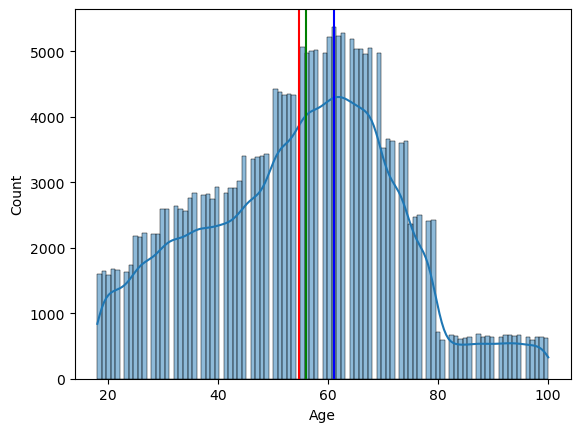

In [18]:
# Plot the mean, Median and mode of age column using sns
sns.histplot(df['Age'], kde=True)
plt.axvline(df['Age'].mean(), color='Red')
plt.axvline(df['Age'].median(), color= 'Green')
plt.axvline(df['Age'].mode()[0], color='Blue')


# print the value of mean, median and mode of age column
print('Mean', df['Age'].mean())
print('Median', df['Age'].median())
print('Mode', df['Age'].mode())

<Axes: xlabel='Age', ylabel='Count'>

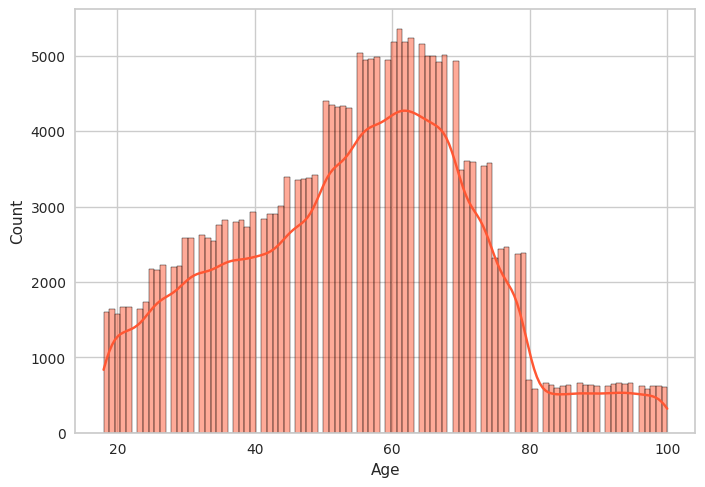

In [ ]:
import seaborn as sns

# Define custom colors
custom_colors = ["#FF5733", "#3366FF", "#33FF57"]  # Example colors, you can adjust as needed

# Plot the histogram with custom colors
sns.histplot(df['Age'], kde=True, color="#FF5733", palette=custom_colors)


In [ ]:
# plot the histogram of age column using plotly and coloring this by sex

fig = px.histogram(data_frame=df, x='Age', color= 'Sex')
fig.show()

In [ ]:
df['Sex'].value_counts()

,count
Sex,
Female,125270
Male,96112


In [ ]:
# calculating the percentage fo male and female value counts in the data

male_count = 96112
female_count = 125270

total_count = male_count + female_count

# calculate percentages
male_percentage = (male_count/total_count)*100
female_percentages = (female_count/total_count)*100

# display the results
print(f'Male percentage i the data: {male_percentage:.2f}%')
print(f'Female percentage in the data : {female_percentages:.2f}%')

# Difference
difference_percentage = ((male_count - female_count)/female_count) * 100
print(f'Males are {difference_percentage:.2f}% more than female in the data.')


Male percentage i the data: 43.41%
Female percentage in the data : 56.59%
Males are -23.28% more than female in the data.


## Explore VegFruit

Unique: [ 64,  50,  61,  74,  67,  72,  59,  90,  53,  65,  70,  35,  46,
        54,  29,  32,  37,  75,  77,  48,  89,  80,  42,  31,  76,  60,
        79,  63,  51,  57,  52,  66,  68,  69,  71,  47,  73,  97,  18,
        49,  55,  39,  82,  88,  62,  43,  30,  56,  34,  78,  58,  40,
        20,  86,  41,  93,  28,  94,  38,  19,  84,  33,  92,  36,  44,
        45, 100,  85,  21,  96,  98,  95,  27,  24,  99,  87,  83,  23,
        26,  25,  91,  22,  81]

Type: object

Have NaN: false

In [ ]:
df['VegFruit'].describe()

,VegFruit
count,221382
unique,2
top,Yes
freq,193349


In [ ]:
df['VegFruit'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df['VegFruit'].value_counts()

,count
VegFruit,
Yes,193349
No,28033


# Handling missing values in HighChol and BMI column

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 221382 entries, 0 to 223083
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   ID            221382 non-null  object 
 1   HeartDisease  221382 non-null  object 
 2   HighBP        221382 non-null  object 
 3   HighChol      189340 non-null  object 
 4   CholCheck     221382 non-null  object 
 5   BMI           209657 non-null  float64
 6   Smoker        221382 non-null  object 
 7   Stroke        221382 non-null  object 
 8   Diabetes      221382 non-null  object 
 9   PhysicalAct   221382 non-null  object 
 10  Alcohol       221382 non-null  object 
 11  HealthCov     221382 non-null  object 
 12  CostBarrier   221382 non-null  object 
 13  GenHealth     221382 non-null  object 
 14  WalkDiff      221382 non-null  object 
 15  Sex           221382 non-null  object 
 16  EduLevel      221382 non-null  object 
 17  Income        221382 non-null  object 
 18  Age      

## Handling missing values in HighChol

In [ ]:
df.to_csv('train_checkpoint.csv')

In [ ]:
print(f"Percentage of missing values in trestbps column: {df['HighChol'].isnull().sum() /len(df) *100:.2f}%")

Percentage of missing values in trestbps column: 14.47%


In [ ]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import train_test_split

# # เลือกเฉพาะแถวที่ไม่มี NaN
# train_data = df.dropna(subset=['HighChol'])

# # แปลง Yes/No เป็น 1/0
# train_data['HighChol'] = train_data['HighChol'].map({'Yes': 1, 'No': 0})

# # เลือกฟีเจอร์ที่สำคัญ
# features = ['HeartDisease', 'HighBP', 'Smoker', 'Diabetes', 'CholCheck', 'Sex', 'Age']
# X = pd.get_dummies(train_data[features], drop_first=True)
# y = train_data['HighChol']

# # สร้างโมเดล Random Forest
# clf = RandomForestClassifier()
# clf.fit(X, y)

# # ทำนายค่าที่หายไป
# missing_data = df[df['HighChol'].isna()]
# X_missing = pd.get_dummies(missing_data[features], drop_first=True)

# predictions = clf.predict(X_missing)
# df.loc[df['HighChol'].isna(), 'HighChol'] = ['Yes' if p == 1 else 'No' for p in predictions]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# 1️⃣ เลือกเฉพาะแถวที่ไม่มี NaN ใน 'HighChol' สำหรับ training
train_data = df.dropna(subset=['HighChol']).copy()

# 2️⃣ แปลง Yes/No เป็น 1/0
train_data['HighChol'] = train_data['HighChol'].map({'Yes': 1, 'No': 0})

# 3️⃣ เลือกฟีเจอร์สำคัญ
features = ['HeartDisease', 'HighBP', 'Smoker', 'Diabetes', 'CholCheck', 'Sex', 'Age']

# 4️⃣ ใช้ get_dummies() และกำหนด columns ที่ต้องการใช้
X_train = pd.get_dummies(train_data[features], drop_first=True)
y_train = train_data['HighChol']

# 5️⃣ Train โมเดล Random Forest
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# 6️⃣ เตรียมข้อมูลที่ต้องการเติมค่าหายไป
missing_data = df[df['HighChol'].isna()].copy()

# 7️⃣ แปลง get_dummies() ให้มี columns เดียวกันกับตอน train
X_missing = pd.get_dummies(missing_data[features], drop_first=True)

# ใช้ reindex() ให้แน่ใจว่า X_missing มี columns เหมือน X_train
X_missing = X_missing.reindex(columns=X_train.columns, fill_value=0)

# 8️⃣ ทำนายค่า HighChol
predictions = clf.predict(X_missing)

# 9️⃣ แทนค่าที่หายไป
df.loc[df['HighChol'].isna(), 'HighChol'] = ['Yes' if p == 1 else 'No' for p in predictions]


In [ ]:
print(f"Percentage of missing values in trestbps column: {df['BMI'].isnull().sum() /len(df) *100:.2f}%")

Percentage of missing values in trestbps column: 5.30%


In [ ]:
# Impute the missing values of trestbps column using iterative imputer
# create an object of iteratvie imputer
imputer1 = IterativeImputer(max_iter=10, random_state=42)

# Fit the imputer on trestbps column
imputer1.fit(df[['BMI']])

# Transform the data
df['BMI'] = imputer1.transform(df[['BMI']])

# Check the missing values in trestbps column
print(f"Missing values in BMI column: {df['BMI'].isnull().sum()}")


Missing values in BMI column: 0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 221382 entries, 0 to 223083
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   ID            221382 non-null  object 
 1   HeartDisease  221382 non-null  object 
 2   HighBP        221382 non-null  object 
 3   HighChol      221382 non-null  object 
 4   CholCheck     221382 non-null  object 
 5   BMI           221382 non-null  float64
 6   Smoker        221382 non-null  object 
 7   Stroke        221382 non-null  object 
 8   Diabetes      221382 non-null  object 
 9   PhysicalAct   221382 non-null  object 
 10  Alcohol       221382 non-null  object 
 11  HealthCov     221382 non-null  object 
 12  CostBarrier   221382 non-null  object 
 13  GenHealth     221382 non-null  object 
 14  WalkDiff      221382 non-null  object 
 15  Sex           221382 non-null  object 
 16  EduLevel      221382 non-null  object 
 17  Income        221382 non-null  object 
 18  Age      

In [ ]:
df.to_csv('train_checkpoint.csv', index=False)

# Label Encoder

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 221382 entries, 0 to 223083
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   ID            221382 non-null  object 
 1   HeartDisease  221382 non-null  object 
 2   HighBP        221382 non-null  object 
 3   HighChol      221382 non-null  object 
 4   CholCheck     221382 non-null  object 
 5   BMI           221382 non-null  float64
 6   Smoker        221382 non-null  object 
 7   Stroke        221382 non-null  object 
 8   Diabetes      221382 non-null  object 
 9   PhysicalAct   221382 non-null  object 
 10  Alcohol       221382 non-null  object 
 11  HealthCov     221382 non-null  object 
 12  CostBarrier   221382 non-null  object 
 13  GenHealth     221382 non-null  object 
 14  WalkDiff      221382 non-null  object 
 15  Sex           221382 non-null  object 
 16  EduLevel      221382 non-null  object 
 17  Income        221382 non-null  object 
 18  Age      

In [ ]:
df.to_csv('/content/drive/MyDrive/AI_Engineer_SS5/Week4/dataset/train_checkpoint.csv', index=False)

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AI_Engineer_SS5/Week4/dataset/train_checkpoint.csv')

In [ ]:
df
['HeartDisease', 'HighBP', 'HighChol', 'Stroke', 'PhysicalAct', 'GenHealth', 'Age']

,ID,HeartDisease,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysicalAct,Alcohol,HealthCov,CostBarrier,GenHealth,WalkDiff,Sex,EduLevel,Income,Age,VegFruit
0,train_000001,No,Yes,Yes,Yes,40.68,Yes,No,No,No,No,Yes,No,Very Poor,Yes,Female,High school graduate,"$15,000 to less than $20,000",64,Yes
1,train_000002,No,No,No,No,24.36,Yes,No,No,Yes,No,No,Yes,Fair,No,Female,College graduate,"Less than $10,000",50,No
2,train_000003,No,Yes,Yes,Yes,27.33,No,No,No,No,No,Yes,Yes,Very Poor,Yes,Female,High school graduate,"$75,000 or more",61,Yes
3,train_000004,No,Yes,No,Yes,27.01,No,No,No,Yes,No,Yes,No,Good,No,Female,Some high school,"$35,000 to less than $50,000",74,Yes
4,train_000006,No,Yes,Yes,Yes,25.11,Yes,No,No,Yes,No,Yes,No,Good,No,Male,College graduate,"$75,000 or more",67,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221377,train_223080,No,No,No,Yes,28.20,No,No,No,No,No,Yes,No,Excellent,No,Female,College graduate,"$25,000 to less than $35,000",34,Yes
221378,train_223081,No,Yes,Yes,Yes,45.01,No,No,No,No,No,Yes,No,Fair,No,Male,College graduate,"$50,000 to less than $75,000",43,Yes
221379,train_223082,No,Yes,Yes,Yes,18.94,No,No,Yes,No,No,Yes,No,Poor,Yes,Female,Elementary,"$20,000 to less than $25,000",72,No
221380,train_223083,No,No,No,Yes,29.29,No,No,No,Yes,No,Yes,No,Excellent,No,Female,Some college or technical school,"($10,000 to less than $15,000",28,Yes


In [ ]:
# split the data into X and y
df

"""encode X data using separate label encoder for all categorical columns and save it for inverse transform"""
# Task: Separate Encoder for all categorical and object columns and inverse transform at the end.
Label_Encoder = LabelEncoder()

for col in df.columns:
    if col != 'ID' and (df[col].dtype == 'object' or df[col].dtype == 'category'):
        df[col] = Label_Encoder.fit_transform(df[col])
    else:
        pass






In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221382 entries, 0 to 221381
Data columns (total 20 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   ID            221382 non-null  object 
 1   HeartDisease  221382 non-null  int64  
 2   HighBP        221382 non-null  int64  
 3   HighChol      221382 non-null  int64  
 4   CholCheck     221382 non-null  int64  
 5   BMI           221382 non-null  float64
 6   Smoker        221382 non-null  int64  
 7   Stroke        221382 non-null  int64  
 8   Diabetes      221382 non-null  int64  
 9   PhysicalAct   221382 non-null  int64  
 10  Alcohol       221382 non-null  int64  
 11  HealthCov     221382 non-null  int64  
 12  CostBarrier   221382 non-null  int64  
 13  GenHealth     221382 non-null  int64  
 14  WalkDiff      221382 non-null  int64  
 15  Sex           221382 non-null  int64  
 16  EduLevel      221382 non-null  int64  
 17  Income        221382 non-null  int64  
 18  Age 

In [ ]:
# X.info()

In [ ]:
# # create a list of models to evaluate

# models = [
#     ('Logistic Regression', LogisticRegression(random_state=42)),
#     ('Gradient Boosting', GradientBoostingClassifier(random_state=42)),
#     ('KNeighbors Classifier', KNeighborsClassifier()),
#     ('Decision Tree Classifier', DecisionTreeClassifier(random_state=42)),
#     ('AdaBoost Classifier', AdaBoostClassifier(random_state=42)),
#     ('Random Forest', RandomForestClassifier(random_state=42)),
#     ('XGboost Classifier', XGBClassifier(objective="binary:logistic",random_state=42)),

#     ('Support Vector Machine', SVC(random_state=42)),

#     ('Naye base Classifier', GaussianNB())


# ]

# best_model = None
# best_accuracy = 0.0

# # Iterate over the models and evaluate their performance
# for name, model in models:
#     # Create a pipeline for each model
#     pipeline = Pipeline([
#         ('model', model)
#     ])

#     # Perform cross validation
#     scores = cross_val_score(pipeline, X_train, y_train, cv=5)

#     # Calculate mean accuracy
#     mean_accuracy = scores.mean()

#     # Fit the pipeline on the training data
#     pipeline.fit(X_train, y_train)

#     # Make prediction on the test data
#     y_pred = pipeline.predict(X_test)

#     # Calculate accuracy score
#     accuracy = accuracy_score(y_test, y_pred)

#     # Print the performance metrics
#     print("Model", name)
#     print("Cross Validatino accuracy: ", mean_accuracy)
#     print("Test Accuracy: ", accuracy)
#     print()

#     # Check if the current model has the best accuracy
#     if accuracy > best_accuracy:
#         best_accuracy = accuracy
#         best_model = pipeline

# # Retrieve the best model
# print("Best Model: ", best_model)





In [ ]:
df

,ID,HeartDisease,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysicalAct,Alcohol,HealthCov,CostBarrier,GenHealth,WalkDiff,Sex,EduLevel,Income,Age,VegFruit
0,train_000001,0,1,1,1,40.68,1,0,0,0,0,1,0,4,1,0,2,0,64,1
1,train_000002,0,0,0,0,24.36,1,0,0,1,0,0,1,1,0,0,0,7,50,0
2,train_000003,0,1,1,1,27.33,0,0,0,0,0,1,1,4,1,0,2,5,61,1
3,train_000004,0,1,0,1,27.01,0,0,0,1,0,1,0,2,0,0,5,3,74,1
4,train_000006,0,1,1,1,25.11,1,0,0,1,0,1,0,2,0,1,0,5,67,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221377,train_223080,0,0,0,1,28.20,0,0,0,0,0,1,0,0,0,0,0,2,34,1
221378,train_223081,0,1,1,1,45.01,0,0,0,0,0,1,0,1,0,1,0,4,43,1
221379,train_223082,0,1,1,1,18.94,0,0,1,0,0,1,0,3,1,0,1,1,72,0
221380,train_223083,0,0,0,1,29.29,0,0,0,1,0,1,0,0,0,0,4,6,28,1


# Features Selection

In [ ]:
correlation_matrix = df[[ 'HeartDisease','HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysicalAct', 'Alcohol', 'HealthCov',
       'CostBarrier', 'GenHealth', 'WalkDiff', 'Sex', 'EduLevel', 'Income',
       'Age', 'VegFruit']].corr()
correlation_matrix

target = ['HighBP',	'HighChol',	'	CholCheck',	'	BMI',	'Smoker',	'	Stroke',	'	Diabetes',	'GenHealth',	'	WalkDiff', ' Age']


In [19]:
# วาด Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

NameError: name 'correlation_matrix' is not defined

<Figure size 1200x800 with 0 Axes>

In [ ]:
df[all_features]

,HeartDisease,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysicalAct,Alcohol,HealthCov,CostBarrier,GenHealth,WalkDiff,Sex,EduLevel,Income,Age,VegFruit
0,0,1,1,1,40.68,1,0,0,0,0,1,0,4,1,0,2,0,64,1
1,0,0,0,0,24.36,1,0,0,1,0,0,1,1,0,0,0,7,50,0
2,0,1,1,1,27.33,0,0,0,0,0,1,1,4,1,0,2,5,61,1
3,0,1,0,1,27.01,0,0,0,1,0,1,0,2,0,0,5,3,74,1
4,0,1,1,1,25.11,1,0,0,1,0,1,0,2,0,1,0,5,67,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221377,0,0,0,1,28.20,0,0,0,0,0,1,0,0,0,0,0,2,34,1
221378,0,1,1,1,45.01,0,0,0,0,0,1,0,1,0,1,0,4,43,1
221379,0,1,1,1,18.94,0,0,1,0,0,1,0,3,1,0,1,1,72,0
221380,0,0,0,1,29.29,0,0,0,1,0,1,0,0,0,0,4,6,28,1


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

all_features = ['HeartDisease','HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysicalAct', 'Alcohol', 'HealthCov',
       'CostBarrier', 'GenHealth', 'WalkDiff', 'Sex', 'EduLevel', 'Income',
       'Age', 'VegFruit']
# ใช้ Random Forest เป็นโมเดลหลัก
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(rf, n_features_to_select=10)  # เลือก 10 Features ที่ดีที่สุด

X_selected = rfe.fit_transform(df[all_features], df['HeartDisease'])
selected_features = df[all_features].columns[rfe.support_]
print(f"Features ที่เลือกใช้: {selected_features}")


Features ที่เลือกใช้: Index(['HeartDisease', 'HighBP', 'HighChol', 'BMI', 'Stroke', 'Diabetes',
       'GenHealth', 'WalkDiff', 'Sex', 'Age'],
      dtype='object')


In [ ]:
import optuna
import numpy as np
import xgboost as xgb
from sklearn.metrics import fbeta_score
from sklearn.model_selection import train_test_split

# กำหนด Features ทั้งหมด
all_features = ['HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysicalAct', 'Alcohol', 'HealthCov',
       'CostBarrier', 'GenHealth', 'WalkDiff', 'Sex', 'EduLevel', 'Income',
       'Age', 'VegFruit']

target = 'HeartDisease'

# แบ่งข้อมูล Train/Test
X_train, X_test, y_train, y_test = train_test_split(df[all_features], df[target], test_size=0.2, random_state=42)

# ฟังก์ชันสำหรับ Optuna
def objective(trial):
    # สร้าง Feature Masking (1=ใช้, 0=ไม่ใช้)
    selected_mask = [trial.suggest_int(f"{feature}", 0, 1) for feature in all_features]

    # เลือกเฉพาะ Features ที่มีค่า 1
    selected_features = [feature for feature, use in zip(all_features, selected_mask) if use == 1]

    # ถ้าไม่มี Feature ถูกเลือกเลย → บังคับให้เลือก 1 ตัว
    if len(selected_features) == 0:
        selected_features = [np.random.choice(all_features)]

    # Train XGBoost Model
    model = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, scale_pos_weight=15, random_state=42)
    model.fit(X_train[selected_features], y_train)

    # Predict และคำนวณ F2-score
    y_pred = model.predict(X_test[selected_features])
    f2 = fbeta_score(y_test, y_pred, beta=2)

    return f2

# ใช้ Optuna สุ่มหา Features ที่ดีที่สุด
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10000)

# แสดง Features ที่ดีที่สุด
best_mask = study.best_trial.params
best_features = [feature for feature, use in best_mask.items() if use == 1]

print("Features ที่ดีที่สุด:", best_features)
print("Best F2-score:", study.best_value)


[I 2025-02-15 18:16:10,589] A new study created in memory with name: no-name-c29fce94-7899-49a3-a635-a5ed7d3bbee5
[W 2025-02-15 18:16:10,691] Trial 0 failed with parameters: {'HeartDisease': 1, 'HighBP': 0, 'HighChol': 1, 'Stroke': 1, 'PhysicalAct': 1, 'GenHealth': 1, 'Age': 1} because of the following error: ValueError("Invalid classes inferred from unique values of `y`.  Expected: [0 1], got ['No' 'Yes']").
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "<ipython-input-301-4cb31a9715fc>", line 29, in objective
    model.fit(X_train[selected_features], y_train)
  File "/usr/local/lib/python3.11/dist-packages/xgboost/core.py", line 726, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py", line 1559, in fit
    raise ValueError(
ValueError: Invalid 

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got ['No' 'Yes']

In [ ]:
import optuna
import numpy as np
import lightgbm as lgb  # ใช้ LightGBM แทน XGBoost
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score
from sklearn.model_selection import train_test_split

# กำหนด Features ทั้งหมด
all_features = ['HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysicalAct', 'Alcohol', 'HealthCov',
       'CostBarrier', 'GenHealth', 'WalkDiff', 'Sex', 'EduLevel', 'Income',
       'Age', 'VegFruit']

target = 'HeartDisease'

# แบ่งข้อมูล Train/Test
X_train, X_test, y_train, y_test = train_test_split(df[all_features], df[target], test_size=0.2, random_state=42)

# ฟังก์ชันสำหรับ Optuna
def objective(trial):
    # สร้าง Feature Masking (1=ใช้, 0=ไม่ใช้)
    selected_mask = [trial.suggest_int(f"{feature}", 0, 1) for feature in all_features]

    # เลือกเฉพาะ Features ที่มีค่า 1
    selected_features = [feature for feature, use in zip(all_features, selected_mask) if use == 1]

    # ถ้าไม่มี Feature ถูกเลือกเลย → บังคับให้เลือก 1 ตัว
    if len(selected_features) == 0:
        selected_features = [np.random.choice(all_features)]

    # ให้ Optuna เลือกโมเดลที่ดีที่สุด
    model_name = trial.suggest_categorical("model", ["RandomForest", "XGB", "CatBoost"])

    if model_name == "RandomForest":
        model = RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 300),
            max_depth=trial.suggest_int("max_depth", 3, 10),
            random_state=42
        )

    elif model_name == "XGB":
        model = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, scale_pos_weight=15, random_state=42)

    elif model_name == "CatBoost":
        model = CatBoostClassifier(
            iterations=trial.suggest_int("iterations", 100, 300),
            depth=trial.suggest_int("depth", 3, 10),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1),
            verbose=0,
            random_state=42
        )
    # Train โมเดล
    model.fit(X_train[selected_features], y_train)

    # Predict และคำนวณ F2-score
    y_pred = model.predict(X_test[selected_features])
    f2 = fbeta_score(y_test, y_pred, beta=2)

    return f2

# ใช้ Optuna หา Features และโมเดลที่ดีที่สุด
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=1000)  # ทดลอง 200 ครั้ง

# แสดง Features และโมเดลที่ดีที่สุด
best_mask = study.best_trial.params
best_features = [feature for feature, use in best_mask.items() if isinstance(use, int) and use == 1]
best_model_name = study.best_trial.params["model"]

print("Features ที่ดีที่สุด:", best_features)
print("โมเดลที่ดีที่สุด:", best_model_name)
print("Best F2-score:", study.best_value)


[I 2025-02-15 13:57:15,351] A new study created in memory with name: no-name-550bb539-eb8f-42aa-a4e3-236727f2993a
[I 2025-02-15 13:57:16,898] Trial 0 finished with value: 0.4784937510144457 and parameters: {'HighBP': 0, 'HighChol': 1, 'CholCheck': 0, 'BMI': 1, 'Smoker': 1, 'Stroke': 1, 'Diabetes': 1, 'PhysicalAct': 0, 'Alcohol': 0, 'HealthCov': 0, 'CostBarrier': 0, 'GenHealth': 1, 'WalkDiff': 0, 'Sex': 1, 'EduLevel': 1, 'Income': 0, 'Age': 0, 'VegFruit': 0, 'model': 'XGB'}. Best is trial 0 with value: 0.4784937510144457.
[I 2025-02-15 13:57:25,176] Trial 1 finished with value: 0.045871559633027525 and parameters: {'HighBP': 0, 'HighChol': 1, 'CholCheck': 0, 'BMI': 0, 'Smoker': 1, 'Stroke': 1, 'Diabetes': 1, 'PhysicalAct': 1, 'Alcohol': 1, 'HealthCov': 1, 'CostBarrier': 1, 'GenHealth': 1, 'WalkDiff': 0, 'Sex': 0, 'EduLevel': 0, 'Income': 1, 'Age': 0, 'VegFruit': 1, 'model': 'CatBoost', 'iterations': 228, 'depth': 10, 'learning_rate': 0.012379339783259308}. Best is trial 0 with value: 0.

KeyboardInterrupt: 

In [ ]:
import optuna
import numpy as np
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score
from sklearn.model_selection import train_test_split

# กำหนด Features ทั้งหมด
all_features = ['HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysicalAct', 'Alcohol', 'HealthCov',
       'CostBarrier', 'GenHealth', 'WalkDiff', 'Sex', 'EduLevel', 'Income',
       'Age', 'VegFruit']

target = 'HeartDisease'

# แบ่งข้อมูล Train/Test
X_train, X_test, y_train, y_test = train_test_split(df[all_features], df[target], test_size=0.2, random_state=42)

# ฟังก์ชันสำหรับ Optuna
def objective(trial):
    # สร้าง Feature Masking (1=ใช้, 0=ไม่ใช้)
    selected_mask = [trial.suggest_int(f"{feature}", 0, 1) for feature in all_features]

    # เลือกเฉพาะ Features ที่มีค่า 1
    selected_features = [feature for feature, use in zip(all_features, selected_mask) if use == 1]

    # ถ้าไม่มี Feature ถูกเลือกเลย → บังคับให้เลือก 1 ตัว
    if len(selected_features) == 0:
        selected_features = [np.random.choice(all_features)]

    # สร้างโมเดลแต่ละตัว
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, scale_pos_weight=15, random_state=42)
    lr_model = LogisticRegression()

    # รวมโมเดลด้วย Voting Classifier
    ensemble_model = VotingClassifier(
        estimators=[
            ("RandomForest", rf_model),
            ("XGBoost", xgb_model),
            ("LogisticRegression", lr_model),
        ],
        voting="hard"
    )

    # Train โมเดล
    ensemble_model.fit(X_train[selected_features], y_train)

    # Predict และคำนวณ F2-score
    y_pred = ensemble_model.predict(X_test[selected_features])
    f2 = fbeta_score(y_test, y_pred, beta=2)

    return f2

# ใช้ Optuna หา Features ที่ดีที่สุด
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200)  # ทดลอง 50 ครั้ง

# แสดง Features ที่ดีที่สุด
best_mask = study.best_trial.params
best_features = [feature for feature, use in best_mask.items() if use == 1]

print("Features ที่ดีที่สุด:", best_features)
print("Best F2-score:", study.best_value)


[I 2025-02-15 12:59:39,359] A new study created in memory with name: no-name-14c9dcd3-125d-468c-9851-21d3fa383ce8
[I 2025-02-15 12:59:59,112] Trial 0 finished with value: 0.20033337449067787 and parameters: {'HighBP': 0, 'HighChol': 1, 'CholCheck': 1, 'BMI': 0, 'Smoker': 0, 'Stroke': 1, 'Diabetes': 1, 'PhysicalAct': 0, 'Alcohol': 0, 'HealthCov': 1, 'CostBarrier': 0, 'GenHealth': 1, 'WalkDiff': 0, 'Sex': 0, 'EduLevel': 0, 'Income': 1, 'Age': 1, 'VegFruit': 1}. Best is trial 0 with value: 0.20033337449067787.
[I 2025-02-15 13:00:15,365] Trial 1 finished with value: 0.21175321901507294 and parameters: {'HighBP': 0, 'HighChol': 0, 'CholCheck': 1, 'BMI': 0, 'Smoker': 1, 'Stroke': 1, 'Diabetes': 0, 'PhysicalAct': 1, 'Alcohol': 0, 'HealthCov': 1, 'CostBarrier': 1, 'GenHealth': 1, 'WalkDiff': 1, 'Sex': 1, 'EduLevel': 1, 'Income': 0, 'Age': 1, 'VegFruit': 0}. Best is trial 1 with value: 0.21175321901507294.
[I 2025-02-15 13:00:37,036] Trial 2 finished with value: 0.18382998653474622 and paramet

KeyboardInterrupt: 

# Fine-tune model and evaluation

In [ ]:
selected_features = ['HeartDisease', 'HighBP', 'HighChol', 'BMI', 'Stroke', 'Diabetes',
       'GenHealth', 'WalkDiff', 'Age']

In [ ]:
df.to_csv('/content/drive/MyDrive/AI_Engineer_SS5/Week4/dataset/train_data.csv', index=False)

In [ ]:
def evaluate_classification_models(X, y, categorical_columns):
    # Encode categorical columns
    X_encoded = X.copy()
    label_encoders = {}
    for col in categorical_columns:
        label_encoders[col] = LabelEncoder()
        X_encoded[col] = label_encoders[col].fit_transform(X[col])

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

    # Define models
    models = {
        "Logistic Regression": LogisticRegression(),
        "KNN": KNeighborsClassifier(),
        "NB": GaussianNB(),
        "SVM": SVC(),
        "Decision Tree": DecisionTreeClassifier(),
        "Random Forest": RandomForestClassifier(),
        "XGBoost": XGBClassifier(),
        "GradientBoosting": GradientBoostingClassifier(),
        "AdaBoost": AdaBoostClassifier()
    }

    # Train and evaluate models
    results = {}
    best_model = None
    best_accuracy = 0.0
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        results[name] = accuracy
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model = name

    return results, best_model


In [ ]:
# !pip install -U pip
!pip install -U setuptools wheel
!pip install autogluon

In [ ]:
df_selected.to_csv('/content/drive/MyDrive/AI_Engineer_SS5/Week4/dataset/train_data_selected_M03.csv', index=False)

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AI_Engineer_SS5/Week4/dataset/train_checkpoint.csv')
# df.drop(['Unnamed: 0', 'ID'], axis=1, inplace=True)
df.head()

,ID,HeartDisease,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysicalAct,Alcohol,HealthCov,CostBarrier,GenHealth,WalkDiff,Sex,EduLevel,Income,Age,VegFruit
0,train_000001,No,Yes,Yes,Yes,40.68,Yes,No,No,No,No,Yes,No,Very Poor,Yes,Female,High school graduate,"$15,000 to less than $20,000",64,Yes
1,train_000002,No,No,No,No,24.36,Yes,No,No,Yes,No,No,Yes,Fair,No,Female,College graduate,"Less than $10,000",50,No
2,train_000003,No,Yes,Yes,Yes,27.33,No,No,No,No,No,Yes,Yes,Very Poor,Yes,Female,High school graduate,"$75,000 or more",61,Yes
3,train_000004,No,Yes,No,Yes,27.01,No,No,No,Yes,No,Yes,No,Good,No,Female,Some high school,"$35,000 to less than $50,000",74,Yes
4,train_000006,No,Yes,Yes,Yes,25.11,Yes,No,No,Yes,No,Yes,No,Good,No,Male,College graduate,"$75,000 or more",67,Yes


In [ ]:
df

"""encode X data using separate label encoder for all categorical columns and save it for inverse transform"""
# Task: Separate Encoder for all categorical and object columns and inverse transform at the end.
Label_Encoder = LabelEncoder()

for col in df.columns:
    if col != 'ID' and (df[col].dtype == 'object' or df[col].dtype == 'category'):
        df[col] = Label_Encoder.fit_transform(df[col])
    else:
        pass

In [ ]:
import numpy as np

class_counts = np.bincount(y_train)
total_samples = len(y_train)
class_weights = {cls: total_samples / count for cls, count in enumerate(class_counts)}
class_weights_array = np.array(list(class_weights.values()))
class_weights_array


array([ 1.08885842, 12.25385733])

In [ ]:
from autogluon.tabular import TabularPredictor
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_sample_weight


# 📌 แยก Train/Test Set
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=y)


# 📌 คำนวณ Weight ของแต่ละ Sample
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

# 📌 คำนวณ Weight Class โดยใช้ Inverse Frequency
class_counts = np.bincount(y_train)
total_samples = len(y_train)
class_weights = {cls: total_samples / count for cls, count in enumerate(class_counts)}
print(class_weights)


# 📌 คำนวณ Weight ของแต่ละ Sample
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
# sample_weights = class_weights_array
print(sample_weights)

# 📌 รวม X และ y เป็น DataFrame สำหรับ AutoGluon
train_data = pd.DataFrame(X_train, columns=X_train.columns)
train_data['diabetes'] = y_train
# train_data['sample_weight'] = train_data['diabetes'].map(class_weights)  # เพิ่มคอลัมน์ weight

test_data = pd.DataFrame(X_test, columns=X_test.columns)
test_data['diabetes'] = y_test
# # Split the data
# X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# smote = SMOTE(random_state=42)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# # 📌 รวม X และ y เป็น DataFrame สำหรับ AutoGluon
# train_data = pd.DataFrame(X_train_resampled, columns=X_train.columns)
# train_data['diabetes'] = y_train_resampled

# test_data = pd.DataFrame(X_test, columns=X_test.columns)
# test_data['diabetes'] = y_test


# # Combine features and target for AutoGluon
# train_data = X_train.copy()
# train_data['diabetes'] = y_train

# test_data = X_test.copy()
# test_data['diabetes'] = y_test

# Define the label column
label_column = 'diabetes'

# 📌 สร้างและเทรนโมเดล AutoGluon พร้อมใช้ sample_weight
predictor = TabularPredictor(label="diabetes", eval_metric="f1").fit(
    train_data, presets=["high_quality"],
    ag_args_fit={"sample_weight": sample_weights}  # ส่ง weight ให้โมเดล
)
# predictor = TabularPredictor(label="diabetes", eval_metric="f1").fit(train_data, sample_weight="sample_weight")

# # Create and train the AutoGluon predictor
# predictor = TabularPredictor(label=label_column).fit(train_data)

# Evaluate the predictor
leaderboard = predictor.leaderboard(test_data)
print(leaderboard)

# Predict on test data
y_pred = predictor.predict(test_data)
print(classification_report(y_test,y_pred))


# Save the predictor
predictor.save('/content/model/autogluon_model')

In [ ]:
# target = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'Diabetes', 'HealthCov', 'GenHealth', 'Sex', 'EduLevel', 'Income', 'Age']
# target = ['HeartDisease','HighBP','HighChol',	'CholCheck',	'BMI',	'Smoker',	'Stroke',	'Diabetes',	'GenHealth',	'WalkDiff', 'Age']
target = ['HeartDisease', 'HighBP', 'HighChol', 'Stroke', 'PhysicalAct', 'GenHealth', 'Age']
df_selected = df[target]

In [ ]:
df_selected

,HeartDisease,HighBP,HighChol,Stroke,PhysicalAct,GenHealth,Age
0,0,1,1,0,0,4,64
1,0,0,0,0,1,1,50
2,0,1,1,0,0,4,61
3,0,1,0,0,1,2,74
4,0,1,1,0,1,2,67
...,...,...,...,...,...,...,...
221377,0,0,0,0,0,0,34
221378,0,1,1,0,0,1,43
221379,0,1,1,0,0,3,72
221380,0,0,0,0,1,0,28


In [ ]:
# prompt: df_selected.loc[:, 'BMI'] = df_selected['BMI'].astype(int) แปลงเป็น Integer ไม่มีทศนิยมหน่อย

df_selected.loc[:, 'BMI'] = df_selected['BMI'].astype(int)


KeyError: 'BMI'

In [ ]:
df_selected

,HeartDisease,HighBP,HighChol,BMI,Stroke,Diabetes,GenHealth,WalkDiff,Age
0,0,1,1,40.0,0,0,4,1,64
1,0,0,0,24.0,0,0,1,0,50
2,0,1,1,27.0,0,0,4,1,61
3,0,1,0,27.0,0,0,2,0,74
4,0,1,1,25.0,0,0,2,0,67
...,...,...,...,...,...,...,...,...,...
221377,0,0,0,28.0,0,0,0,0,34
221378,0,1,1,45.0,0,0,1,0,43
221379,0,1,1,18.0,0,1,3,1,72
221380,0,0,0,29.0,0,0,0,0,28


In [ ]:
df_selected

,HighBP,HighChol,CholCheck,Smoker,Stroke,Diabetes,HealthCov,GenHealth,Sex,EduLevel,Income,Age
0,1,1,1,1,0,0,1,4,0,2,0,64
1,0,0,0,1,0,0,0,1,0,0,7,50
2,1,1,1,0,0,0,1,4,0,2,5,61
3,1,0,1,0,0,0,1,2,0,5,3,74
4,1,1,1,1,0,0,1,2,1,0,5,67
...,...,...,...,...,...,...,...,...,...,...,...,...
221377,0,0,1,0,0,0,1,0,0,0,2,34
221378,1,1,1,0,0,0,1,1,1,0,4,43
221379,1,1,1,0,0,1,1,3,0,1,1,72
221380,0,0,1,0,0,0,1,0,0,4,6,28


In [ ]:
target = ['HeartDisease', 'HighBP', 'HighChol', 'Stroke', 'PhysicalAct', 'GenHealth', 'Age']
df_selected = df[target]
X_train, X_test, y_train, y_test = train_test_split(df_selected[target], df['HeartDisease'], test_size=0.2, random_state=42, stratify=df['HeartDisease'])

In [ ]:
X_train

,HeartDisease,HighBP,HighChol,Stroke,PhysicalAct,GenHealth,Age
133389,0,0,0,0,1,0,50
93201,0,0,0,0,0,1,41
55132,0,0,0,0,0,3,51
34576,0,0,0,0,0,1,78
138077,0,0,0,0,1,2,35
...,...,...,...,...,...,...,...
92991,0,0,0,0,1,0,19
58420,0,0,0,0,1,0,49
71522,0,0,0,0,1,0,46
13165,0,1,0,0,1,1,59


In [ ]:
# คำนวณ Weight Class
class_counts = np.bincount(df['HeartDisease'])
total_samples = len(df['HeartDisease'])
class_weights = {cls: total_samples / count for cls, count in enumerate(class_counts)}
print(class_weights)

{0: 1.0888567550020658, 1: 12.254068415808701}


In [ ]:
# prompt: อยากได้เฉพาะ value ของ class_weights

class_weights_array = np.array(list(class_weights.values()))
class_weights_array


array([ 1.08885676, 12.25406842])

In [ ]:
X_train = X_train.drop(columns=['HeartDisease'])
X_train

,HighBP,HighChol,Stroke,PhysicalAct,GenHealth,Age
133389,0,0,0,1,0,50
93201,0,0,0,0,1,41
55132,0,0,0,0,3,51
34576,0,0,0,0,1,78
138077,0,0,0,1,2,35
...,...,...,...,...,...,...
92991,0,0,0,1,0,19
58420,0,0,0,1,0,49
71522,0,0,0,1,0,46
13165,1,0,0,1,1,59


In [ ]:

X_test = X_test.drop(columns=['HeartDisease'])
X_test

,HighBP,HighChol,Stroke,PhysicalAct,GenHealth,Age
32138,1,1,0,0,3,63
124063,1,1,0,1,1,56
27332,1,1,1,1,2,67
36557,0,0,0,1,3,57
151514,0,1,0,0,4,53
...,...,...,...,...,...,...
194606,0,0,0,1,1,44
92332,0,0,0,1,0,60
198245,0,1,0,1,2,43
109677,0,0,0,1,0,55


In [ ]:

y_train

,HeartDisease
133389,0
93201,0
55132,0
34576,0
138077,0
...,...
92991,0
58420,0
71522,0
13165,0


In [ ]:
X_train

,HighBP,HighChol,CholCheck,Smoker,Stroke,Diabetes,HealthCov,GenHealth,Sex,EduLevel,Income,Age
133389,0,0,1,0,0,0,1,0,0,4,3,50
93201,0,0,0,0,0,0,1,1,1,0,3,41
55132,0,0,0,1,0,0,1,3,0,2,7,51
34576,0,0,1,0,0,0,1,1,0,4,5,78
138077,0,0,1,0,0,0,1,2,1,0,5,35
...,...,...,...,...,...,...,...,...,...,...,...,...
92991,0,0,1,0,0,0,1,0,1,2,6,19
58420,0,0,1,0,0,0,1,0,0,0,5,49
71522,0,0,1,1,0,0,0,0,1,5,3,46
13165,1,0,1,0,0,0,0,1,0,1,7,59


In [ ]:
# คำนวณอัตราส่วนของคลาส
num_negative = y_train.value_counts()[0]
num_positive = y_train.value_counts()[1]

scale_pos_weight = num_negative / num_positive
print(f"Scale Pos Weight: {scale_pos_weight}")


Scale Pos Weight: 11.253857330657995


In [ ]:
X_train

,HighBP,HighChol,Stroke,PhysicalAct,GenHealth,Age
133389,0,0,0,1,0,50
93201,0,0,0,0,1,41
55132,0,0,0,0,3,51
34576,0,0,0,0,1,78
138077,0,0,0,1,2,35
...,...,...,...,...,...,...
92991,0,0,0,1,0,19
58420,0,0,0,1,0,49
71522,0,0,0,1,0,46
13165,1,0,0,1,1,59


In [ ]:
import pandas as pd
import xgboost as xgb
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import fbeta_score, roc_auc_score

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=300,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=3,
    gamma=0.2,
    reg_lambda=2,
    reg_alpha=1,
    random_state=42,
    verbosity=1
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.2, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [ ]:
import optuna



target = ['HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysicalAct', 'HealthCov',
       'GenHealth', 'WalkDiff', 'Sex', 'EduLevel', 'Income',
       'Age']
df_selected = df[target]
X_train, X_test, y_train, y_test = train_test_split(df_selected[target], df['HeartDisease'], test_size=0.2, random_state=42, stratify=df['HeartDisease'])


def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 4, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05),  # ✅ ลด Learning Rate
        "n_estimators": trial.suggest_int("n_estimators", 200, 400),
        "scale_pos_weight": trial.suggest_int("scale_pos_weight", 5, 99),  # ✅ ลด Weight ของ Class 1
        "min_child_weight": trial.suggest_int("min_child_weight", 2, 6),  # ✅ ป้องกัน Overfitting
        "gamma": trial.suggest_float("gamma", 0, 0.3),
        "subsample": trial.suggest_float("subsample", 0.7, 0.9),  # ✅ ใช้ข้อมูลหลากหลายขึ้น
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.8),
    }

    model = xgb.XGBClassifier(**params, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    f2 = fbeta_score(y_test, preds, beta=2)
    return f2

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print("Best hyperparameters:", study.best_params)

[I 2025-02-15 20:17:22,598] A new study created in memory with name: no-name-f98bbaed-b6e2-4ea5-a5ff-b1ec99a67f37
[I 2025-02-15 20:17:27,236] Trial 0 finished with value: 0.41901625361323036 and parameters: {'max_depth': 4, 'learning_rate': 0.017885852614670367, 'n_estimators': 322, 'scale_pos_weight': 76, 'min_child_weight': 3, 'gamma': 0.2312093072961572, 'subsample': 0.7832359210901398, 'colsample_bytree': 0.7374132225079495}. Best is trial 0 with value: 0.41901625361323036.
[I 2025-02-15 20:17:33,078] Trial 1 finished with value: 0.44699428218204296 and parameters: {'max_depth': 7, 'learning_rate': 0.019970623505626436, 'n_estimators': 300, 'scale_pos_weight': 62, 'min_child_weight': 2, 'gamma': 0.20805004051792275, 'subsample': 0.7302037610822895, 'colsample_bytree': 0.7724966193382063}. Best is trial 1 with value: 0.44699428218204296.
[I 2025-02-15 20:17:35,569] Trial 2 finished with value: 0.4622717508055854 and parameters: {'max_depth': 6, 'learning_rate': 0.03918772722546797, 

Best hyperparameters: {'max_depth': 6, 'learning_rate': 0.04035309586000743, 'n_estimators': 285, 'scale_pos_weight': 10, 'min_child_weight': 4, 'gamma': 0.16197008989204092, 'subsample': 0.7697042673927961, 'colsample_bytree': 0.7802443474331134}


In [ ]:
study.best_params

{'max_depth': 6,
 'learning_rate': 0.04045333503265588,
 'n_estimators': 277,
 'scale_pos_weight': 12,
 'min_child_weight': 3,
 'gamma': 0.13864152760911655,
 'subsample': 0.7899483143294475,
 'colsample_bytree': 0.799625822174017}

In [ ]:
# ดึงค่าพารามิเตอร์ที่ดีที่สุดจาก Optuna
best_params = study.best_params
best_model = xgb.XGBClassifier(**best_params, random_state=42)

# เทรนโมเดลใหม่ด้วยค่าพารามิเตอร์ที่ดีที่สุด
best_model.fit(X_train, y_train)

# ทำนายผลลัพธ์
y_pred = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]  # ความน่าจะเป็นของ Class 1

# คำนวณ AUC
auc = roc_auc_score(y_test, y_pred_prob)
print(f"AUC: {auc:.4f}")

# คำนวณ F2-score
f2_score = fbeta_score(y_test, y_pred, beta=2)
print(f"F2-score: {f2_score:.4f}")

# บันทึกโมเดลเป็นไฟล์ .pkl
joblib.dump(best_model, "/content/drive/MyDrive/AI_Engineer_SS5/Week4/best_model/best_xgboost_06_model.pkl")
print("📂 Model saved as best_xgboost_06_model.pkl")

AUC: 0.8638
F2-score: 0.5443
📂 Model saved as best_xgboost_06_model.pkl


# Prediction

In [ ]:
df_test = pd.read_csv('/content/drive/MyDrive/AI_Engineer_SS5/Week4/dataset/test.csv')


,ID,High Blood Pressure,Told High Cholesterol,Cholesterol Checked,Body Mass Index,Smoked 100+ Cigarettes,Diagnosed Stroke,Diagnosed Diabetes,Leisure Physical Activity,Heavy Alcohol Consumption,Health Care Coverage,Doctor Visit Cost Barrier,General Health,Difficulty Walking,Sex,Education Level,Income Level,Age,Vegetable or Fruit Intake (1+ per Day)
0,test_000001,Yes,Yes,Yes,24.84,No,No,No,Yes,No,Yes,No,Good,No,Female,Some college or technical school,"$20,000 to less than $25,000",71,Yes
1,test_000002,Yes,No,Yes,29.08,Yes,No,No,No,No,Yes,No,Fair,No,Female,College graduate,"$50,000 to less than $75,000",61,No
2,test_000003,Yes,Yes,Yes,35.23,Yes,No,No,No,No,Yes,No,Fair,Yes,Female,Some college or technical school,"Less than $10,000",67,Yes
3,test_000004,No,No,Yes,24.78,Yes,No,No,No,No,Yes,No,Fair,No,Female,Some college or technical school,"$50,000 to less than $75,000",50,Yes
4,test_000005,No,No,Yes,27.57,Yes,No,No,No,No,Yes,No,Fair,No,Male,Some college or technical school,"$25,000 to less than $35,000",40,Yes


In [ ]:
df_test.rename(columns={
    'ID': 'ID',
    'High Blood Pressure': 'HighBP',
    'Told High Cholesterol': 'HighChol',
    'Cholesterol Checked': 'CholCheck',
    'Body Mass Index': 'BMI',
    'Smoked 100+ Cigarettes': 'Smoker',
    'Diagnosed Stroke': 'Stroke',
    'Diagnosed Diabetes': 'Diabetes',
    'Leisure Physical Activity': 'PhysicalAct',
    'Heavy Alcohol Consumption': 'Alcohol',
    'Health Care Coverage': 'HealthCov',
    'Doctor Visit Cost Barrier': 'CostBarrier',
    'General Health': 'GenHealth',
    'Difficulty Walking': 'WalkDiff',
    'Sex': 'Sex',
    'Education Level': 'EduLevel',
    'Income Level': 'Income',
    'Age': 'Age',
    'Vegetable or Fruit Intake (1+ per Day)': 'VegFruit'
}, inplace=True)
Label_Encoder = LabelEncoder()

for col in df_test.columns:
    if col != 'ID' and df_test[col].dtype == 'object' or df_test[col].dtype == 'category':
        df_test[col] = Label_Encoder.fit_transform(df_test[col])
    else:
        pass

In [ ]:
import joblib
import xgboost as xgb

loaded_model = joblib.load("/content/drive/MyDrive/AI_Engineer_SS5/Week4/best_model/best_xgboost_06_model.pkl")

target = ['HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysicalAct', 'HealthCov',
       'GenHealth', 'WalkDiff', 'Sex', 'EduLevel', 'Income',
       'Age']
df_selected_test = df_test[target]

preds = loaded_model.predict(df_selected_test)


In [ ]:
df_test['predictions'] = preds

merged_df = df_test


,ID,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysicalAct,Alcohol,HealthCov,CostBarrier,GenHealth,WalkDiff,Sex,EduLevel,Income,Age,VegFruit,predictions
0,test_000001,1,1,1,24.84,0,0,0,1,0,1,0,2,0,0,4,1,71,1,0
1,test_000002,1,0,1,29.08,1,0,0,0,0,1,0,1,0,0,0,4,61,0,0
2,test_000003,1,1,1,35.23,1,0,0,0,0,1,0,1,1,0,4,7,67,1,1
3,test_000004,0,0,1,24.78,1,0,0,0,0,1,0,1,0,0,4,4,50,1,0
4,test_000005,0,0,1,27.57,1,0,0,0,0,1,0,1,0,1,4,2,40,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74356,test_074357,1,0,1,22.85,0,0,0,0,0,1,0,1,0,0,4,6,47,1,0
74357,test_074358,1,1,1,28.27,1,0,0,0,0,1,0,1,0,0,2,4,71,1,1
74358,test_074359,1,1,1,25.88,0,0,1,0,0,1,0,4,1,0,0,1,90,1,1
74359,test_074360,1,1,1,23.74,0,1,0,0,0,1,1,3,0,1,5,6,59,0,1


In [ ]:
# prompt: นับจำนวน ที่เป็น 0, 1 merged_df['predictions']

zero_count = (merged_df['predictions'] == 0).sum()
one_count = (merged_df['predictions'] == 1).sum()

print(f"Number of 0s in 'predictions': {zero_count}")
print(f"Number of 1s in 'predictions': {one_count}")


Number of 0s in 'predictions': 50690
Number of 1s in 'predictions': 23671


In [ ]:
merged_df['History of HeartDisease or Attack'] = merged_df['predictions'].apply(lambda x: 'No' if x == 0 else 'Yes')


In [ ]:
df_result = merged_df[['ID', 'History of HeartDisease or Attack']]

df_result.to_csv('/content/drive/MyDrive/AI_Engineer_SS5/Week4/dataset/week4_submission_v04.csv', index=False)

In [ ]:
# ทำนายผลลัพธ์
y_pred = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]  # ความน่าจะเป็นของ Class 1

# คำนวณ AUC
auc = roc_auc_score(y_test, y_pred_prob)
print(f"AUC: {auc:.4f}")

# คำนวณ F2-score (เน้น Recall มากกว่า Precision)
f2_score = fbeta_score(y_test, y_pred, beta=2)
print(f"F2-score: {f2_score:.4f}")


AUC: 0.8474
F2-score: 0.4103


In [ ]:
# ✅ บันทึกโมเดลเป็น `.pkl`
joblib.dump(xgb_model, "/content/drive/MyDrive/AI_Engineer_SS5/Week4/best_model/xgboost_02_model.pkl")
print("Model saved as xgboost_model.pkl")


Model saved as xgboost_model.pkl


In [ ]:
import optuna
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# ✅ กำหนด Features และ Target
# all_features = ['HighBP', 'HighChol', 'CholCheck', 'BMI',
#        'Smoker', 'Stroke', 'Diabetes', 'PhysicalAct', 'Alcohol', 'HealthCov',
#        'CostBarrier', 'GenHealth', 'WalkDiff', 'Sex', 'EduLevel', 'Income',
#        'Age', 'VegFruit']
# target = 'HeartDisease'

# # ✅ แบ่งข้อมูล Train/Test
# X_train, X_test, y_train, y_test = train_test_split(df[all_features], df[target], test_size=0.2, random_state=42, stratify=df[target])

target = ['HeartDisease', 'HighBP', 'HighChol', 'Stroke', 'PhysicalAct', 'GenHealth', 'Age']
df_selected = df[target]
X_train, X_test, y_train, y_test = train_test_split(df_selected[target], df['HeartDisease'], test_size=0.2, random_state=42, stratify=df['HeartDisease'])


# ✅ ใช้ SMOTE ทำ Oversampling
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

def objective(trial):
    # เลือกโมเดลที่ดีที่สุด
    model_name = trial.suggest_categorical("model", ["RandomForest", "LogisticRegression"])

    if model_name == "RandomForest":
        model = RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 500),  # จำนวนต้นไม้
            max_depth=trial.suggest_int("max_depth", 3, 15),  # ความลึกของต้นไม้
            min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
            class_weight="balanced",  # แก้ปัญหา Imbalance
            random_state=42
        )

    elif model_name == "LogisticRegression":
        model = LogisticRegression(
            C=trial.suggest_float("C", 0.01, 10.0, log=True),  # Strength ของ Regularization
            max_iter=trial.suggest_int("max_iter", 100, 500),
            class_weight="balanced",  # แก้ปัญหา Imbalance
            solver="liblinear",
            random_state=42
        )

    model.fit(X_train_resampled, y_train_resampled)

    # Predict และคำนวณ F2-score
    y_pred = model.predict(X_test)
    f2 = fbeta_score(y_test, y_pred, beta=2)

    return f2

# ✅ ใช้ Optuna หาโมเดลที่ดีที่สุด
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)  # ทดลอง 100 ครั้ง

# ✅ แสดงโมเดลที่ดีที่สุด
best_model_name = study.best_trial.params["model"]
print("📌 โมเดลที่ดีที่สุด:", best_model_name)
print("📌 Best F2-score:", study.best_value)


[I 2025-02-15 19:52:50,874] A new study created in memory with name: no-name-255cbd09-c6e2-4f94-a4e9-fd8f31d5112f
[I 2025-02-15 19:53:12,572] Trial 0 finished with value: 1.0 and parameters: {'model': 'RandomForest', 'n_estimators': 462, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 5}. Best is trial 0 with value: 1.0.
[I 2025-02-15 19:53:13,421] Trial 1 finished with value: 1.0 and parameters: {'model': 'LogisticRegression', 'C': 2.267858735684556, 'max_iter': 122}. Best is trial 0 with value: 1.0.
[I 2025-02-15 19:53:14,186] Trial 2 finished with value: 1.0 and parameters: {'model': 'LogisticRegression', 'C': 0.9202510972774378, 'max_iter': 134}. Best is trial 0 with value: 1.0.
[I 2025-02-15 19:53:14,884] Trial 3 finished with value: 1.0 and parameters: {'model': 'LogisticRegression', 'C': 1.1246570837117704, 'max_iter': 455}. Best is trial 0 with value: 1.0.
[I 2025-02-15 19:53:15,431] Trial 4 finished with value: 1.0 and parameters: {'model': 'LogisticRegression', '

KeyboardInterrupt: 

In [ ]:
!pip install h2o

In [ ]:
import h2o
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,13 mins 29 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.6
H2O_cluster_version_age:,3 months and 13 days
H2O_cluster_name:,H2O_from_python_unknownUser_vdpfu3
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [ ]:
import h2o
from h2o.automl import H2OAutoML
import pandas as pd
from sklearn.model_selection import train_test_split

h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,13 mins 32 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.6
H2O_cluster_version_age:,3 months and 13 days
H2O_cluster_name:,H2O_from_python_unknownUser_vdpfu3
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [ ]:

# แปลงเป็น H2OFrame
train_h2o = h2o.H2OFrame(train_df)
test_h2o = h2o.H2OFrame(test_df)

# กำหนด target เป็น factor (สำหรับ classification)
#target_factor = ['HeartDisease', 'HighBP', 'HighChol', 'BMI', 'Smoker',  'Diabetes', 'Alcohol', 'GenHealth', 'WalkDiff', 'Sex', 'Age']
train_h2o[target] = train_h2o[target].asfactor()
test_h2o[target] = test_h2o[target].asfactor()

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [ ]:


# ตรวจสอบ Imbalanced Data
train_h2o['HeartDisease'].table()

# # 📌 คำนวณ Weight Class โดยใช้ Inverse Frequency
class_counts = train_h2o['HeartDisease'].table().as_data_frame()
print(class_counts)

# คำนวณ class_sampling_factors อัตโนมัติ
class_ratios = class_counts["Count"].max() / class_counts["Count"]
class_sampling_factors = class_ratios.values.tolist()
print(f"class_sampling_factors: {class_sampling_factors}")

# สร้าง AutoML Model พร้อมปรับ class balance
aml = H2OAutoML(
    max_models=30,  # จำนวนโมเดลที่ต้องการเทรน
    seed=42,
    # nfolds=5,
    # balance_classes=True,  # ใช้การปรับสมดุล Class
    class_sampling_factors=class_sampling_factors,  # 🔥 เพิ่มการเรียนรู้ของ Class 1
    # stopping_metric="AUC",
    # max_runtime_secs=300  # กำหนดเวลารวมสูงสุด
    max_runtime_secs=5200  # กำหนดเวลารวมสูงสุด
)

# เทรนโมเดล
aml.train(x=['HeartDisease', 'HighBP', 'HighChol', 'BMI', 'Stroke', 'Diabetes', 'GenHealth', 'WalkDiff', 'Age'], y='HeartDisease', training_frame=train_h2o)

# ดูโมเดลที่ดีที่สุด
leader = aml.leader
print(leader)

   HeartDisease   Count
0             0  162586
1             1   14519
class_sampling_factors: [1.0, 11.198154142847304]
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
Model Details
H2OStackedEnsembleEstimator : Stacked Ensemble
Model Key: StackedEnsemble_AllModels_1_AutoML_2_20250215_91910


Model Summary for Stacked Ensemble: 
key                                        value
-----------------------------------------  ----------------
Stacking strategy                          cross_validation
Number of base models (used / total)       16/30
# GBM base models (used / total)           6/10
# XGBoost base models (used / total)       2/10
# GLM base models (used / total)           1/1
# DeepLearning base models (used / total)  6/7
# DRF base models (used / total)           1/2
Metalearner algorithm                      GLM
Metalearner fold assignment scheme         Random
Metalearner nfolds                         5
Metalearner fold_column

In [ ]:
from sklearn.metrics import fbeta_score

# พยากรณ์ผลลัพธ์
preds = leader.predict(test_h2o)

# แปลงเป็น Pandas DataFrame
preds_df = preds.as_data_frame()
print(preds_df.head())

# ดูค่า AUC
perf = leader.model_performance(test_h2o)
print("AUC:", perf.auc())

f2 = perf.F2()
print(f"F2:{f2}")

y_true = test_h2o['HeartDisease'].as_data_frame().values.ravel()  # ค่าจริง
y_pred = preds_df["predict"].values  # ค่าที่ทำนาย

# คำนวณ F2-score
f2 = fbeta_score(y_true, y_pred, beta=2)
print("F2-score:", f2)

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
   predict        p0        p1
0        0  0.888389  0.111611
1        0  0.964308  0.035692
2        0  0.972864  0.027136
3        0  0.997851  0.002149
4        0  0.999784  0.000216
AUC: 0.8529727455609777
F2:[[0.10045252950449127, 0.5316369419516074]]
F2-score: 0.44970324151575103


In [ ]:
h2o.save_model(leader, path="/content/drive/MyDrive/AI_Engineer_SS5/Week4/best_model_h2o", force=True)


'/content/drive/MyDrive/AI_Engineer_SS5/Week4/best_model_h2o/StackedEnsemble_AllModels_1_AutoML_2_20250215_91910'